Import all the libraries and tools needed below.

In [19]:
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

Set the paths to the dataset files. The `archive/` folder is expected to sit alongside this notebook.

In [20]:
ARCHIVE_DIR  = os.path.join(os.path.dirname(os.path.abspath("__file__")), "archive")
CAPTIONS_CSV = os.path.join(ARCHIVE_DIR, "captions.txt")
IMAGES_DIR   = os.path.join(ARCHIVE_DIR, "Images")

random.seed(42)

### 1)

Load `captions.txt` and print its shape, column names, and null counts to confirm the file loaded correctly.

In [21]:
df = pd.read_csv(CAPTIONS_CSV)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nNull values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (40455, 2)
Columns: ['image', 'caption']

Null values:
image      0
caption    0
dtype: int64

First 5 rows:


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


The dataset has two columns: `image` (filename) and `caption` (text). There are no null values.

### 2)

Count the number of unique images and verify that every image has exactly 5 captions.

In [22]:
n_images  = df["image"].nunique()
print("Unique images:", n_images)

caps_per  = df.groupby("image")["caption"].count()
print("Captions per image (stats):")
print(caps_per.describe())

print("\nImages with exactly 5 captions:",
      (caps_per == 5).sum(), "out of", n_images)

Unique images: 8091
Captions per image (stats):
count    8091.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
Name: caption, dtype: float64

Images with exactly 5 captions: 8091 out of 8091


Every image has exactly 5 human-written captions, giving 8,091 × 5 = 40,455 rows total. This multi-reference structure is important at evaluation time: BLEU score is computed against all 5 references simultaneously.

### 3)

Tokenize the captions (lowercase, split on non-alphabetic characters) and compute caption length statistics.

In [23]:
def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

df["tokens"]      = df["caption"].apply(tokenize)
df["caption_len"] = df["tokens"].apply(len)

print("Caption length (words):")
print(df["caption_len"].describe().round(2))

Caption length (words):
count    40455.00
mean        10.81
std          3.77
min          1.00
25%          8.00
50%         10.00
75%         13.00
max         36.00
Name: caption_len, dtype: float64


Captions average about 11 words and range from 1 to 36. The distribution is fairly tight, which means the LSTM decoder will not need to handle extreme sequence lengths.

### 4)

Plot the distribution of caption lengths.

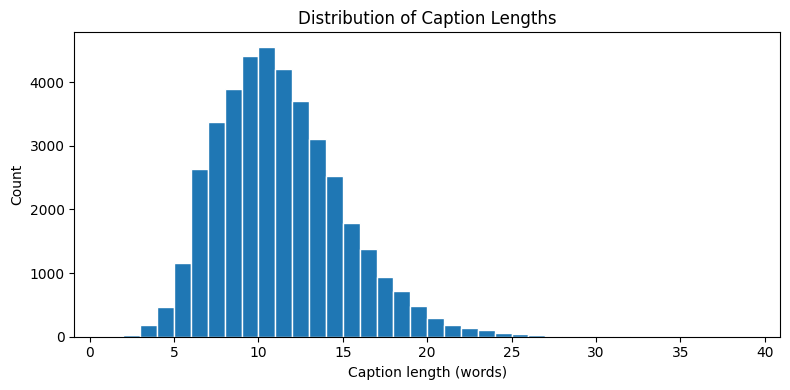

In [24]:
plt.figure(figsize = (8, 4))
plt.hist(df["caption_len"], bins = range(1, 40), edgecolor="white")
plt.xlabel("Caption length (words)")
plt.ylabel("Count")
plt.title("Distribution of Caption Lengths")
plt.tight_layout()
plt.show()

### 5)

Build the vocabulary and print the top 30 most frequent words, the total vocabulary size, and the number of words that appear only once (hapax legomena).

In [25]:
all_tokens = [t for tokens in df["tokens"] for t in tokens]
vocab      = Counter(all_tokens)
hapax      = [w for w, c in vocab.items() if c == 1]

print(f"Total tokens (with repeats) : {len(all_tokens):,}")
print(f"Vocabulary size             : {len(vocab):,}")
print(f"Hapax legomena (count = 1)  : {len(hapax):,}")
print()

top30 = pd.DataFrame(vocab.most_common(30), columns=["word", "count"])
print("Top 30 most common words:")
top30

Total tokens (with repeats) : 437,429
Vocabulary size             : 8,441
Hapax legomena (count = 1)  : 3,310

Top 30 most common words:


,word,count
0,a,62992
1,in,18986
2,the,18419
3,on,10745
4,is,9345
5,and,8862
6,dog,8138
7,with,7765
8,man,7274
9,of,6723


The full vocabulary has 8,441 unique tokens, but 3,310 of them appear only once. For the LSTM tokenizer it is standard practice to replace these with a special `<UNK>` token, which reduces the effective vocabulary to roughly 5,100 words and makes the embedding layer much more manageable.

### 6)

Visualize the top 20 most frequent words as a bar chart.

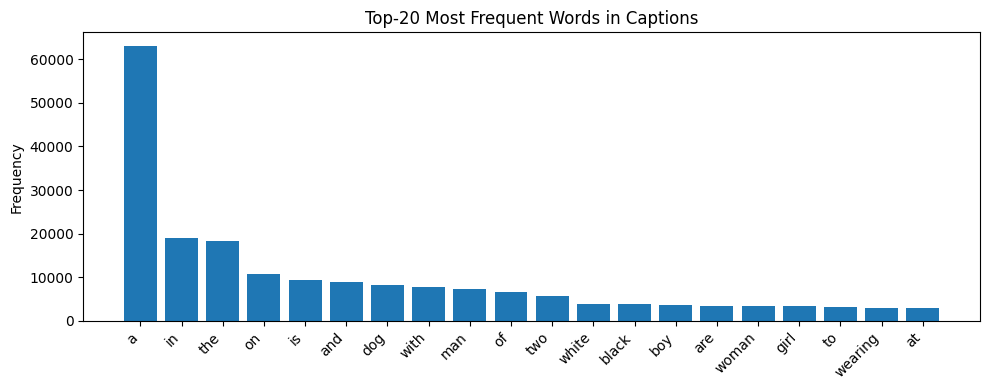

In [26]:
top20 = pd.DataFrame(vocab.most_common(20), columns=["word", "count"])

plt.figure(figsize=(10, 4))
plt.bar(top20["word"], top20["count"])
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Frequency")
plt.title("Top-20 Most Frequent Words in Captions")
plt.tight_layout()
plt.show()

Function words (`a`, `in`, `the`) dominate, as expected for natural English. Content words like `dog`, `man`, `boy`, `woman`, and `girl` rank highly, reflecting the typical subjects of the Flickr photos.

### 7)

Audit the `Images/` directory: count files, check extensions, and cross-reference filenames against the captions CSV to detect any mismatches.

In [27]:
image_files = sorted(os.listdir(IMAGES_DIR))
extensions  = Counter(os.path.splitext(f)[1].lower() for f in image_files)

print("Files in Images/    :", len(image_files))
print("Extensions          :", dict(extensions))

captioned_set       = set(df["image"])
ondisk_set          = set(image_files)
in_csv_not_disk     = captioned_set - ondisk_set
in_disk_not_csv     = ondisk_set - captioned_set

print("\nIn CSV but missing from disk :", len(in_csv_not_disk))
print("On disk but missing from CSV :", len(in_disk_not_csv))

Files in Images/    : 8091
Extensions          : {'.jpg': 8091}

In CSV but missing from disk : 0
On disk but missing from CSV : 0


In [28]:
modes = Counter()
for fname in image_files:
    with Image.open(os.path.join(IMAGES_DIR, fname)) as img:
        modes[img.mode] += 1

print('Color modes across all images:')
for mode, count in modes.most_common():
    print(f'  {mode} : {count}')

Color modes across all images:
  RGB : 8091


All 8,091 images are present on disk and referenced in the CSV with no orphans in either direction. No cleaning is needed for the file index. And all images are RGB.

### 8)

Sample 200 images and inspect their pixel dimensions to understand how much resizing will be needed before feeding into ResNet-50 (which expects 224 × 224).

In [29]:
sample_files = random.sample(image_files, 200)
widths, heights = [], []

for fname in sample_files:
    with Image.open(os.path.join(IMAGES_DIR, fname)) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  — mean: {np.mean(widths):.0f}px  "
      f"min: {np.min(widths)}px  max: {np.max(widths)}px")
print(f"Height — mean: {np.mean(heights):.0f}px  "
      f"min: {np.min(heights)}px  max: {np.max(heights)}px")

Width  — mean: 455px  min: 164px  max: 500px
Height — mean: 395px  min: 198px  max: 500px


### 9)

Visualize the image dimension spread with a scatter plot, marking the 224 px target for ResNet-50.

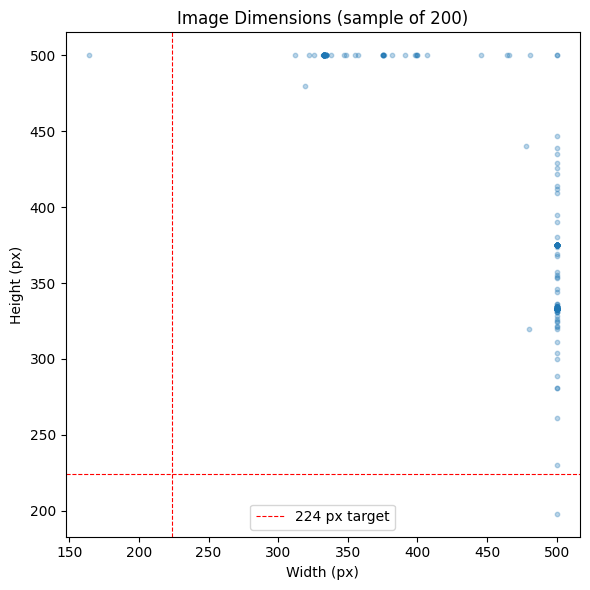

In [30]:
plt.figure(figsize = (6, 6))
plt.scatter(widths, heights, alpha = 0.3, s = 10)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Dimensions (sample of 200)")
plt.axvline(224, color = "red", linestyle = "--", linewidth = 0.8, label = "224 px target")
plt.axhline(224, color = "red", linestyle = "--", linewidth = 0.8)
plt.legend()
plt.tight_layout()
plt.show()

Images are mostly wider than they are tall and cluster around 500 × 375 px — all larger than the 224 × 224 target. This means resizing will downsample rather than upscale, which is preferable for preserving image quality. The `ImageDataGenerator` or `tf.image.resize` can handle this during preprocessing.

### 10)

Display 6 randomly sampled images alongside two of their five reference captions to get an intuition for what the captioning task looks like.

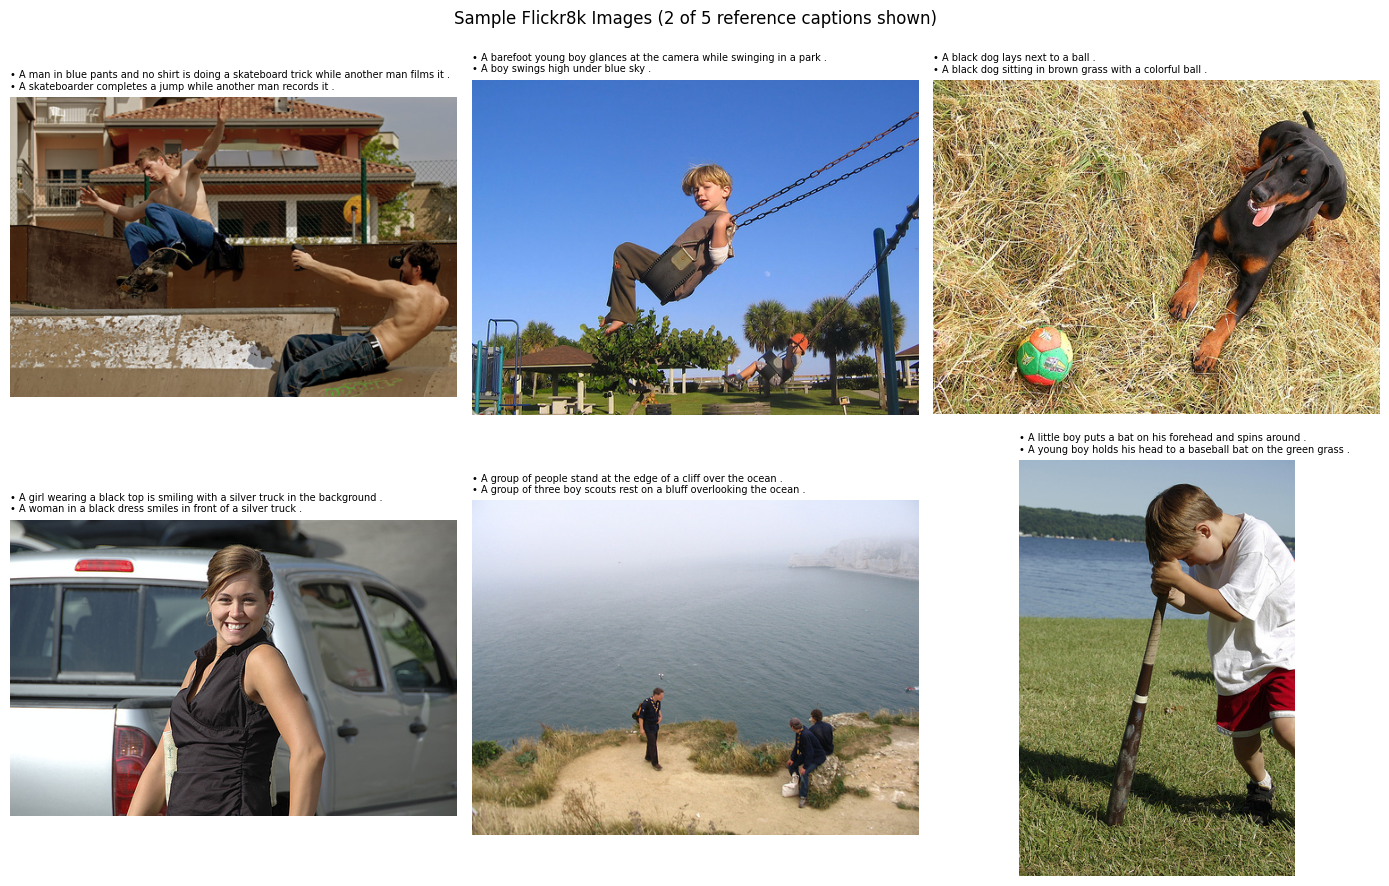

In [31]:
usable      = list(captioned_set & ondisk_set)
sample_imgs = random.sample(usable, 6)

fig, axes = plt.subplots(2, 3, figsize = (14, 9))
for ax, img_name in zip(axes.flat, sample_imgs):
    img      = mpimg.imread(os.path.join(IMAGES_DIR, img_name))
    captions = df[df["image"] == img_name]["caption"].tolist()
    ax.imshow(img)
    ax.axis("off")
    caption_text = "\n".join(f"• {c}" for c in captions[:2])
    ax.set_title(caption_text, fontsize = 7, loc = "left")

plt.suptitle("Sample Flickr8k Images (2 of 5 reference captions shown)", fontsize = 12)
plt.tight_layout()
plt.show()

### 11)

Define the train / val / test split (75% / 12.5% / 12.5%) using a fixed random seed for reproducibility, and report the resulting sizes and training vocabulary coverage.

Circumvent the data leakage problem through spliting the data by unique image identifier, not dataframe row. 

In [32]:
all_image_names = list(captioned_set & ondisk_set)
random.seed(42)
random.shuffle(all_image_names)

n_total = len(all_image_names)
n_train = int(0.75  * n_total)
n_val   = int(0.125 * n_total)

train_imgs = all_image_names[:n_train]
val_imgs   = all_image_names[n_train : n_train + n_val]
test_imgs  = all_image_names[n_train + n_val :]

train_df   = df[df["image"].isin(train_imgs)]
train_vocab = set(t for tokens in train_df["tokens"] for t in tokens)

print(f"Total usable images : {n_total}")
print(f"  Train             : {len(train_imgs):>5}  ({len(train_imgs)/n_total:.1%})")
print(f"  Val               : {len(val_imgs):>5}  ({len(val_imgs)/n_total:.1%})")
print(f"  Test              : {len(test_imgs):>5}  ({len(test_imgs)/n_total:.1%})")
print(f"\nTraining captions   : {len(train_df):,}")
print(f"Training vocab size : {len(train_vocab):,}  "
      f"({len(train_vocab)/len(vocab):.1%} of full vocab)")

Total usable images : 8091
  Train             :  6068  (75.0%)
  Val               :  1011  (12.5%)
  Test              :  1012  (12.5%)

Training captions   : 30,340
Training vocab size : 7,467  (88.5% of full vocab)


The training split covers 88% of the full vocabulary. The remaining 12% of words that appear only in val/test will be handled by the `<UNK>` token. The fixed seed (`random.seed(42)`) ensures this split is reproducible across all three model pipelines.